In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from pandas import read_csv
df=read_csv("train.csv")

In [2]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Student_ID', 'Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications', 'Backlogs']
Categorical Features: ['Gender', 'Degree', 'Branch', 'Placement_Status']


In [3]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                      Student_ID       Age      CGPA  Internships  Projects  \
Student_ID              1.000000  0.002245  0.001977     0.002858  0.002683   
Age                     0.002245  1.000000  0.002480    -0.003742 -0.000880   
CGPA                    0.001977  0.002480  1.000000     0.367628  0.708759   
Internships             0.002858 -0.003742  0.367628     1.000000  0.505756   
Projects                0.002683 -0.000880  0.708759     0.505756  1.000000   
Coding_Skills           0.004786 -0.003190  0.485787     0.519205  0.896575   
Communication_Skills   -0.001191 -0.004219  0.001603     0.003693  0.001265   
Aptitude_Test_Score     0.000601  0.004475  0.707579     0.260352  0.502745   
Soft_Skills_Rating     -0.000949 -0.000476  0.001493     0.000992  0.004829   
Certifications          0.003045  0.001611  0.561624     0.460924  0.828197   
Backlogs               -0.000016  0.000329 -0.575653    -0.204971 -0.401139   

                      C

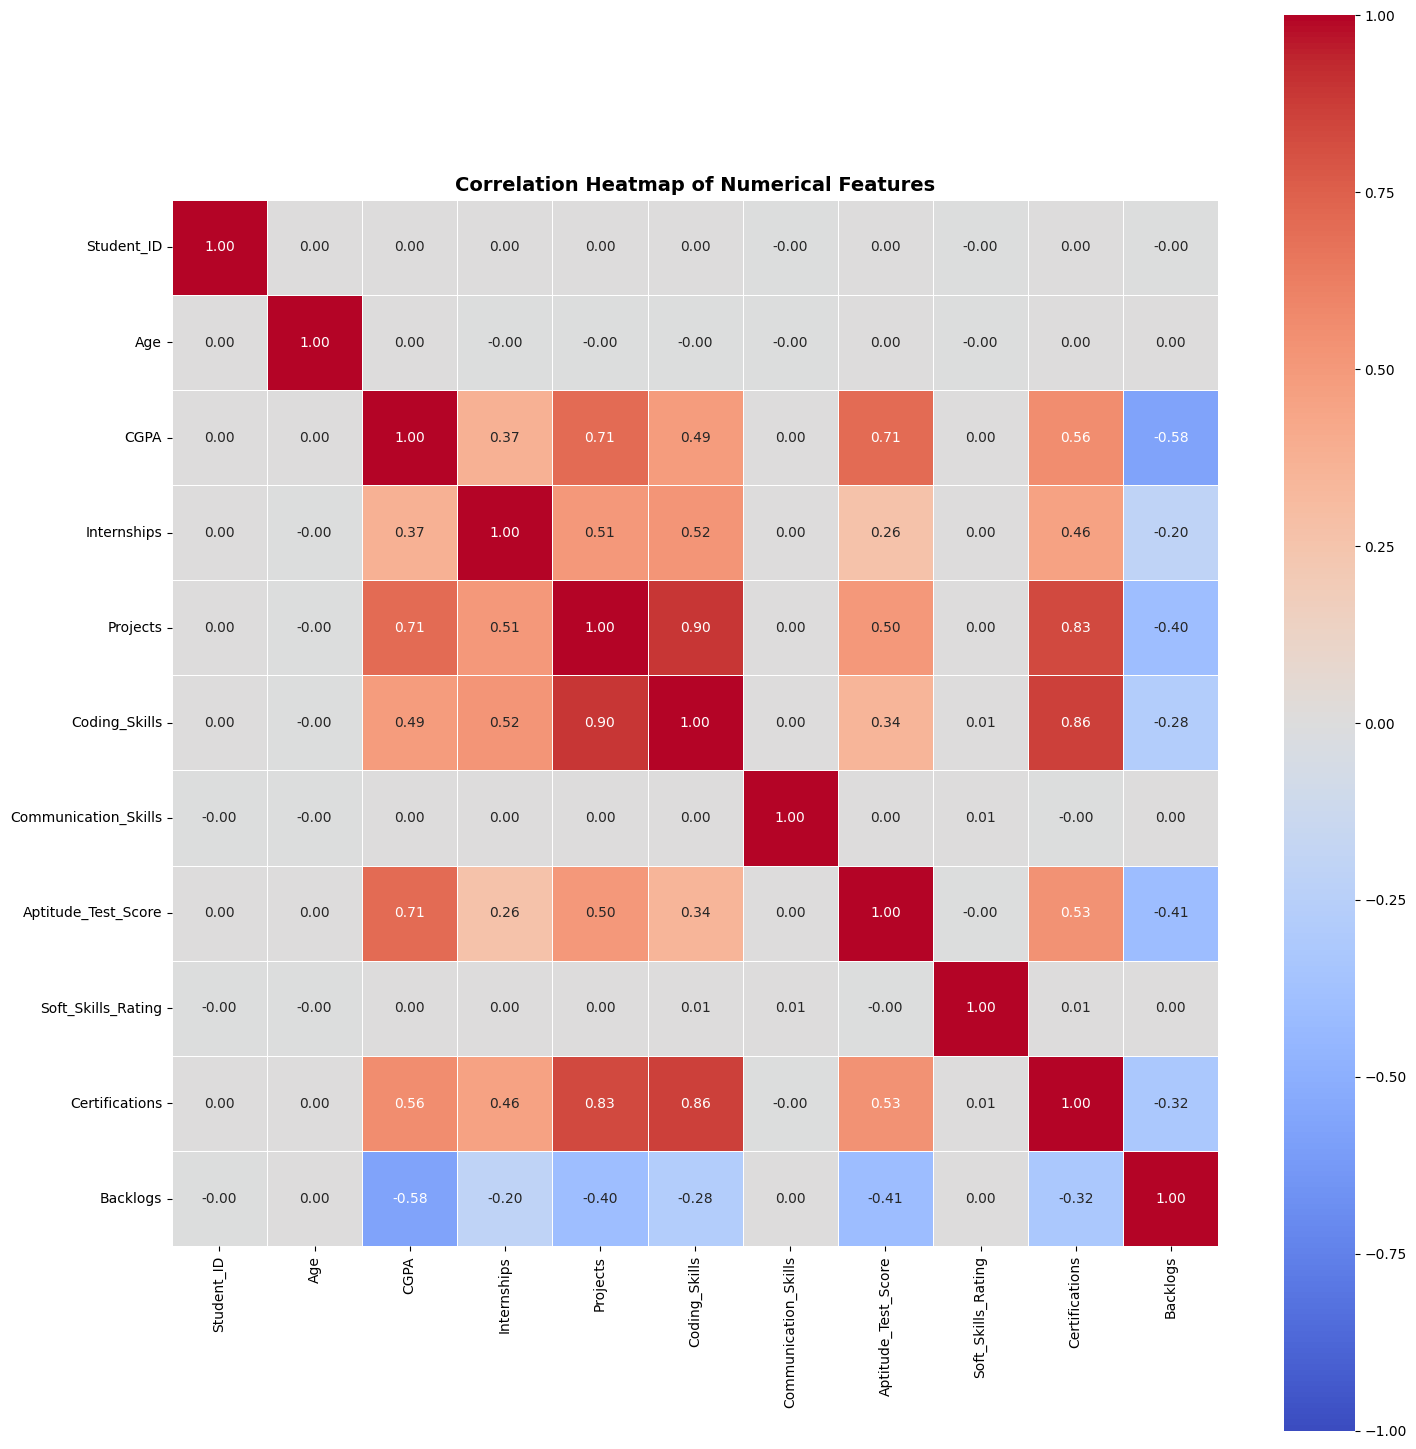

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [5]:
missing_data = pd.DataFrame({

    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_data

,Missing Values,Percentage
Student_ID,0,0.0
Age,0,0.0
Gender,0,0.0
Degree,0,0.0
Branch,0,0.0
CGPA,0,0.0
Internships,0,0.0
Projects,0,0.0
Coding_Skills,0,0.0
Communication_Skills,0,0.0


In [6]:
df = df.drop_duplicates()
df.shape

(45000, 15)

In [7]:
df["Placement_Status"].value_counts()

,count
Placement_Status,
Not Placed,28688
Placed,16312


In [8]:
(df["Placement_Status"].value_counts(normalize=True) * 100).round(2)

,proportion
Placement_Status,
Not Placed,63.75
Placed,36.25
